plan check importance of each frequency band after adjusting for distance of perturbation

also check how well explanation functions unvocers channel importance on normal and distance adjusted samples

In [1]:
import pathlib
import random
import copy
import numpy as np
import torch

from captum.attr import *
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
import yaml
import argparse
from data.data_loader import load_eeg_data, get_sliding_window_data, create_dataloader
import os
import mne
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

from sliced_wasserstein import sliced_wasserstein_distance
from c2st import c2st_knn, c2st_nn, c2st_rf

from models.s4net import S4PatchedFinalNet,TrunkNet, HeadNet
import seaborn as sns

CUDA extension for structured kernels (Cauchy and Vandermonde multiplication) not found. Install by going to extensions/kernels/ and running `python setup.py install`, for improved speed and memory efficiency. Note that the kernel changed for state-spaces 4.0 and must be recompiled.


In [2]:
CFG_YAML = """
wandb:
 key: f0c92a0059bf12e2647f0a1c22fdcd12555fa6df
model:
dataset:
 data_directory: /home/marco/Documents/GitHub/tms_eeg_decoding/data
 #file_name: subject_{:03d}_preprocessed_combined_py.fif
 file_name: subject_{:03d}_preprocessed_combined_py.fif
 exclude_timepoints: 100
 subject_index: 1
 test_subject_indices: [1,2,13,24,26,27,29,34,35,41, 42,43,45,46,47,48,52,55,56,57,60,62,67,69,72,73,79,80,86,88,92,102]
 #test_subject_indices: [2]
training:
 training_start_len: 100
 pretrain_epochs: 100
 pretrain_lr: 0.0001
 val_window_len: 1
 epochs_per_window: 10
 num_warmup_epochs: 5
 num_epochs: 800
 slide_step: 1
 num_warmup_epochs_per_window: 0
 lr: 0.005 #maybe change back to 0.0001
 nll_beta: 0.001
 num_warmup_epochs: 0
 batch_size: 50 #better to use 50
 random_seed: 42
 precision: bf16
 kde_lambda: 0.5
 finetune_entire_model: true # Set to true to finetune the entire model, false for transformer only
exp_name: S4_S4EEGNet_ema
"""

def load_config():
    cfg = OmegaConf.create(yaml.safe_load(CFG_YAML))
    cfg.exp_name = f"{cfg.exp_name}_subject_{cfg.dataset.subject_index}"
    return cfg

def parse_args():
    parser = argparse.ArgumentParser()
    parser.add_argument("--update_conf", nargs="*", help="Updates to the configuration in the form of key=value pairs", default=[])
    parser.add_argument("-f", "--fff", help="A dummy argument to handle IPython's default argument", default="1")
    return parser.parse_args()

def update_config(cfg, cli_args):
    for update in cli_args.update_conf:
        key, value = update.split("=")
        try:
            value = eval(value)
        except:
            pass
        OmegaConf.update(cfg, key, value, force_add=True)
    cfg.exp_name = cfg.exp_name + "_" + "_".join(cli_args.update_conf)
    print(OmegaConf.to_yaml(cfg))
    return cfg


def save_config(cfg):
    os.makedirs("conf/sweeps", exist_ok=True)
    os.makedirs("exp/withinsubs", exist_ok=True)
    with open(f"conf/sweeps/withinsubs_{cfg.exp_name}.yaml", "w") as f:
        f.write(OmegaConf.to_yaml(cfg))

first get accumulated absolute prediction difference over all channels per frequency band for all channels and top 5, top 10

In [3]:
# adujst correctly for repetition
import pickle


def load_predicted_amplitude_for_subject(subject_index=2, rep=1):
    data_dir = f"/home/marco/Documents/GitHub/tms_eeg_decoding/subject_interpretability/gradshap_explanations_rep_{rep}"
    file_path = os.path.join(data_dir, f"gradshap_data_subject_{subject_index}_rep_{rep}.npy")

    #with open(file_path, 'rb') as f:
    #    subject_data = pickle.load(f)   
    #predictions, uncertainties, _ = subject_data['predictions'], subject_data['uncertainties'], subject_data['explanations']
    data = np.load(file_path, allow_pickle=True).item()
    predictions = data['predictions']
    cfg = load_config()
    cfg.dataset.subject_index = subject_index
    _, _, _, _, _, _, _, ch_names = load_eeg_data(cfg)
    
    return predictions,  ch_names

In [4]:

def calculate_diff_per_channel(pred_label_original, freq_bands, amplification_factors, ch_names, subject_index=2, rep=1):
    dir_constrained = "/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_phase/parallel_perturbation_phase"
    mean_diff_per_channel = {}
    median_diff_per_channel = {}

    for band_name, (low_freq, high_freq) in freq_bands.items():
        mean_diff_per_channel[band_name] = {}
        median_diff_per_channel[band_name] = {}
        for factor in amplification_factors:
            file_path = f"parallel_perturbed_prediction_dict_{band_name}_channel_phase_shift_{factor}°_subject_{subject_index}_rep_{rep}.npy"
            load_path = os.path.join(dir_constrained, file_path)
            perturbed_data = np.load(load_path, allow_pickle=True).item()
            mean_diff_per_channel[band_name][factor] = {}
            median_diff_per_channel[band_name][factor] = {}
            for ch_name in ch_names:
                perturbed_amplitude = perturbed_data[ch_name]
                diff = np.abs(pred_label_original - perturbed_amplitude)
                mean_diff_per_channel[band_name][factor][ch_name] = np.mean(diff)
                median_diff_per_channel[band_name][factor][ch_name] = np.median(diff)
    
    return mean_diff_per_channel, median_diff_per_channel

In [5]:

def get_prediction_diff(mean_diff_per_channel, median_diff_per_channel, freq_bands, amplification_factors):
    prediction_diff_mean = {}
    prediction_diff_median = {}
    
    for band_name in freq_bands.keys():
        prediction_diff_mean[band_name] = {}
        prediction_diff_median[band_name] = {}
        
        for factor in amplification_factors:
            mean_diffs = mean_diff_per_channel[band_name][factor]
            median_diffs = median_diff_per_channel[band_name][factor]
            
            # Store the prediction differences without sorting
            prediction_diff_mean[band_name][factor] = mean_diffs
            prediction_diff_median[band_name][factor] = median_diffs
    
    return prediction_diff_mean, prediction_diff_median

#prediction_diff_mean_unsorted, prediction_diff_median_unsorted = get_prediction_diff(mean_diff_per_channel, median_diff_per_channel, freq_bands, #amplification_factors)

In [8]:
freq_bands = {
              "delta": (0, 4),
              "theta": (4, 8),             
              "alpha": (8, 12),
              "beta": (12, 30),
              "gamma": (30, 45)}
phase_perturbations = np.arange(45, 316, 45)


In [9]:
cfg = load_config()

all_subjects_median_diff = {}
for subject_index in cfg.dataset.test_subject_indices:
    original_predictions, ch_names = load_predicted_amplitude_for_subject(subject_index=subject_index, rep=1)
    
    mean_diff_per_channel, median_diff_per_channel = calculate_diff_per_channel(original_predictions, freq_bands, phase_perturbations, ch_names, subject_index=subject_index, rep=1)
    prediction_diff_mean_unsorted, prediction_diff_median_unsorted = get_prediction_diff(mean_diff_per_channel, median_diff_per_channel, freq_bands, phase_perturbations)
    all_subjects_median_diff[subject_index] = prediction_diff_median_unsorted



Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)

In [10]:
def sum_pred_diffs(subject_diffs, relevant_channels=None, aggregation='mean'):
    sum_diffs = {}
    # for each band separately the prediction differences for each trial are summed up
    # if aggregation="mean" the mean over all perturbation settings (factors) is taken
    for band_name, factors in subject_diffs.items():
        for factor, ch_diffs in factors.items():
            if band_name not in sum_diffs:
                sum_diffs[band_name] = {}
            if factor not in sum_diffs[band_name]:
                sum_diffs[band_name][factor] = 0
           
            if relevant_channels is not None:
                for ch_name in relevant_channels:
                    sum_diffs[band_name][factor] += ch_diffs[ch_name]
            else:
                for ch_name, diff in ch_diffs.items():
                    sum_diffs[band_name][factor] += diff
    if aggregation is None:
        return sum_diffs

    # take the mean over all factors                
    sum_diffs_avg = {}                
    if aggregation == 'mean':
        for band_name, factors in sum_diffs.items():
            sum_diffs_avg[band_name] = []
            for factor, _ in factors.items():
                sum_diffs_avg[band_name].append(sum_diffs[band_name][factor])
            sum_diffs_avg[band_name] = np.mean(sum_diffs_avg[band_name])
    return sum_diffs, sum_diffs_avg

In [11]:
all_subjects_sum_diffs = {}
all_subjects_avg_diffs = {}
for subject_index, subject_diffs in all_subjects_median_diff.items():
    all_subjects_sum_diffs[subject_index], all_subjects_avg_diffs[subject_index] = sum_pred_diffs(subject_diffs, relevant_channels=None, aggregation='mean')

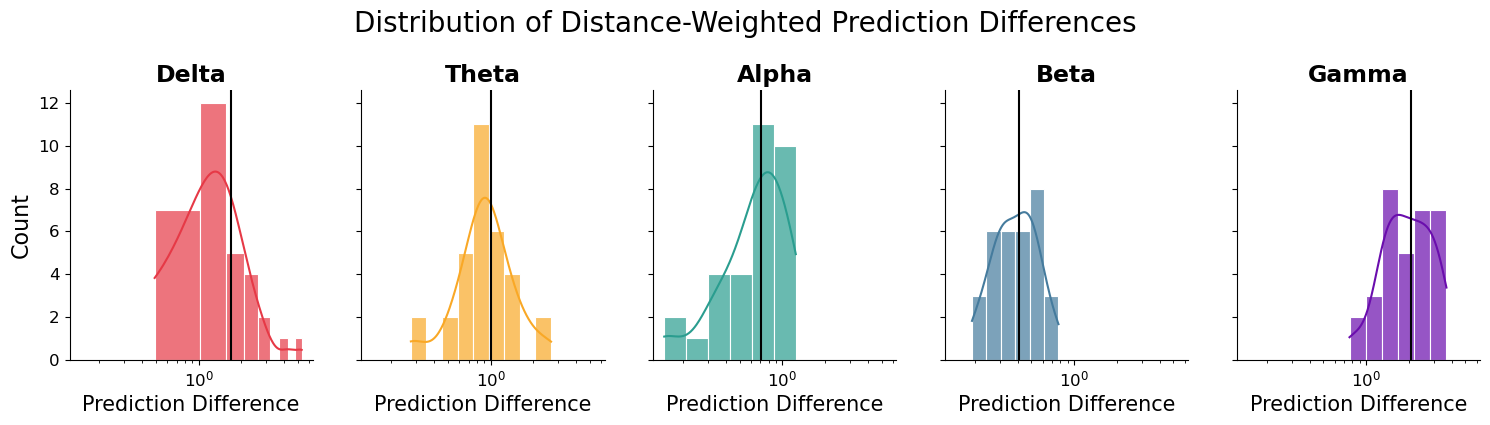

In [ ]:
def plot_frequency_band_distributions_average(all_subjects_avg_diffs, freq_bands, figsize=(15, 4), sharey=True, sharex=True, xlog=False):
    """
    Plot histograms showing the distribution of average differences by frequency band.
    
    Parameters:
    -----------
    all_subjects_avg_diffs : dict
        Dictionary containing average differences per subject
    freq_bands : dict
        Dictionary of frequency bands with format {band_name: (low_freq, high_freq)}
    figsize : tuple, optional
        Size of the figure (width, height)
    sharey, sharex : bool, optional
        Whether to share y-axis and x-axis across subplots
    xlog : bool, optional
        Whether to use log scale for x-axis
        
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The figure containing the plots
    axes : numpy.ndarray
        Array of axes objects
    """
    # Define colors for each frequency band with better color scheme
    colors = {
        'delta': '#E63946',  # Crimson red
        'theta': '#F9A826',  # Orange
        'alpha': '#2A9D8F',  # Teal
        'beta':  '#457B9D',  # Blue
        'gamma': '#6A0DAD',  # Purple
    }
    
    # Create a subplot for each frequency band in a single row
    fig, axes = plt.subplots(nrows=1, ncols=len(freq_bands), figsize=figsize, sharey=sharey, sharex=sharex)
    fig.suptitle('Distribution of Distance-Weighted Prediction Differences', fontsize=20, y=1.05)

    # Collect data for each frequency band and calculate statistics
    band_means = {}
    band_medians = {}
    
    for band_name in freq_bands.keys():
        band_data = [subject_values[band_name] for subject_id, subject_values in all_subjects_avg_diffs.items()]
        band_means[band_name] = np.mean(band_data)
        band_medians[band_name] = np.median(band_data)

    # Plot each frequency band
    for i, band_name in enumerate(freq_bands.keys()):
        band_data = [subject_values[band_name] for subject_id, subject_values in all_subjects_avg_diffs.items()]
        
        # Plot histogram with kernel density estimate
        sns.histplot(
            band_data, 
            kde=True, 
            ax=axes[i], 
            color=colors[band_name],
            alpha=0.7,
            edgecolor='white',
            linewidth=0.8,
   
        )
        
        if xlog:
            axes[i].set_xscale('log')
        
        # Calculate mean and median, add vertical lines
        mean_value = band_means[band_name]
        median_value = band_medians[band_name]
        
        axes[i].axvline(x=mean_value, color='black', linestyle='-', linewidth=1.5, 
                       label=f'Mean: {mean_value:.3e}')
   
        
        # Title and labels with nicer formatting
        axes[i].set_title(f'{band_name.capitalize()}', 
                         fontsize=17, fontweight='bold')
        
        if i == 0:  # Only set y-label for the first subplot
            axes[i].set_ylabel('Count', fontsize=16)
        axes[i].set_xlabel('Prediction Difference', fontsize=15)
        
        # Format the ticks
        axes[i].tick_params(axis='both', labelsize=14)
     
        
        # Remove top and right spines for cleaner look
        sns.despine(ax=axes[i])

    plt.tight_layout()
    plt.subplots_adjust(top=0.85, wspace=0.2)
    
    return fig, axes

# Call the function with the existing data
fig, axes = plot_frequency_band_distributions_average(all_subjects_avg_diffs, freq_bands, xlog=True)


In [13]:

def plot_frequency_band_distributions(sum_pred_diffs, freq_bands, figsize=(15, 20), sharey=True, sharex=True):
    """
        Plot histograms showing the distribution of differences by frequency band and amplification factor.
        
        Parameters:
        -----------
        sum_pred_diffs : dict
            Dictionary containing summed differences per subject, structured as {subject_id: {band_name: {factor: value}}}
        freq_bands : dict
            Dictionary of frequency bands with format {band_name: (low_freq, high_freq)}
        figsize : tuple, optional
            Size of the figure (width, height)
        sharey, sharex : bool, optional
            Whether to share y-axis and x-axis across subplots
            
        Returns:
        --------
        fig : matplotlib.figure.Figure
            The figure containing the plots
        axes : numpy.ndarray
            Array of axes objects
    """
    # Get unique amplification factors from the first subject
    first_subject_id = list(sum_pred_diffs.keys())[0]
    first_band = list(sum_pred_diffs[first_subject_id].keys())[0]
    all_factors = sorted(list(sum_pred_diffs[first_subject_id][first_band].keys()))
        
    # Create a subplot grid: one row per amplification factor, one column per frequency band
    fig, axes = plt.subplots(nrows=len(all_factors), ncols=len(freq_bands), 
                             figsize=figsize, sharey=sharey, sharex=sharex)
    fig.suptitle('Distribution weighted prediction differences', fontsize=16)
    
    # For each amplification factor
    for i, factor in enumerate(all_factors):
        # For each frequency band
        for j, band_name in enumerate(freq_bands.keys()):
            # Collect data for this band and factor across all subjects
            band_data = []
            for subject_id, subject_data in sum_pred_diffs.items():
                if band_name in subject_data and factor in subject_data[band_name]:
                    band_data.append(subject_data[band_name][factor])
                
            # Get the appropriate axes object
            if len(all_factors) > 1 and len(freq_bands) > 1:
               ax = axes[i, j]
            elif len(all_factors) > 1:
                ax = axes[i]
            elif len(freq_bands) > 1:
                ax = axes[j]
            else:
                ax = axes
                
            # Plot histogram for this frequency band and amplification factor
            sns.histplot(band_data, kde=True, ax=ax)
                
            # Calculate mean and add vertical line
            if band_data:
                mean_value = np.mean(band_data)
                ax.axvline(x=mean_value, color='red', linestyle='--', label=f'Mean: {mean_value:.3f}')
                
            # Set titles and labels
            if i == 0:
                ax.set_title(f'{band_name.capitalize()} Band ({freq_bands[band_name][0]}-{freq_bands[band_name][1]} Hz)')
            if j == 0:
                ax.set_ylabel(f'Factor: {factor}\nCount')
            if i == len(all_factors) - 1:
                ax.set_xlabel('Difference')
                
            ax.legend(fontsize='small')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.9, hspace=0.3)
        
    return fig, axes

In [14]:
#plot_frequency_band_distributions(all_subjects_sum_diffs, freq_bands)

In [11]:
def load_distances(subject_index, factors, rep=1):
    dir = "/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_phase/parallel_perturbation_distance_phase"
    
    distances = {}

    for band_name, (low_freq, high_freq) in freq_bands.items():
        distances[band_name] = {}

        for factor in factors:
            file_path = f"parallel_distance_dict_{band_name}_channel_phase_shift_{factor}°_subject_{subject_index}_rep_{rep}.npy"
            load_path = os.path.join(dir, file_path)
            distances[band_name][factor] = np.load(load_path, allow_pickle=True).item()

    return distances

In [12]:

def calculate_diff_per_channel_distance_weighted(pred_label_original, freq_bands, amplification_factors, ch_names, distances, subject_index=2, rep=1):
    dir_constrained = "/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_phase/parallel_perturbation_phase"
    mean_diff_per_channel = {}
    median_diff_per_channel = {}

    for band_name, (low_freq, high_freq) in freq_bands.items():
        mean_diff_per_channel[band_name] = {}
        median_diff_per_channel[band_name] = {}
        for factor in amplification_factors:
            file_path = f"parallel_perturbed_prediction_dict_{band_name}_channel_phase_shift_{factor}°_subject_{subject_index}_rep_{rep}.npy"
            load_path = os.path.join(dir_constrained, file_path)
            perturbed_data = np.load(load_path, allow_pickle=True).item()
            mean_diff_per_channel[band_name][factor] = {}
            median_diff_per_channel[band_name][factor] = {}
            for ch_name in ch_names:
                perturbed_amplitude = np.array(perturbed_data[ch_name])
                diff = np.abs(pred_label_original - perturbed_amplitude)/np.array(distances[band_name][factor][ch_name])
                mean_diff_per_channel[band_name][factor][ch_name] = np.mean(diff)
                median_diff_per_channel[band_name][factor][ch_name] = np.median(diff)
    
    return mean_diff_per_channel, median_diff_per_channel

In [13]:
cfg = load_config()

all_subjects_median_diff_distance_weighted = {}
for subject_index in cfg.dataset.test_subject_indices:
    original_predictions, ch_names = load_predicted_amplitude_for_subject(subject_index=subject_index)
    distances = load_distances(subject_index, phase_perturbations, rep=1)
    mean_diff_per_channel, median_diff_per_channel = calculate_diff_per_channel_distance_weighted(original_predictions, freq_bands, phase_perturbations, ch_names, distances, subject_index=subject_index, rep=1)
    prediction_diff_mean_unsorted, prediction_diff_median_unsorted = get_prediction_diff(mean_diff_per_channel, median_diff_per_channel, freq_bands, phase_perturbations)
    all_subjects_median_diff_distance_weighted[subject_index] = prediction_diff_median_unsorted

Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)

In [14]:
all_subjects_sum_diffs = {}
all_subjects_avg_diffs = {}
for subject_index, subject_diffs in all_subjects_median_diff_distance_weighted.items():
    all_subjects_sum_diffs[subject_index], all_subjects_avg_diffs[subject_index] = sum_pred_diffs(subject_diffs, relevant_channels=None, aggregation='mean')

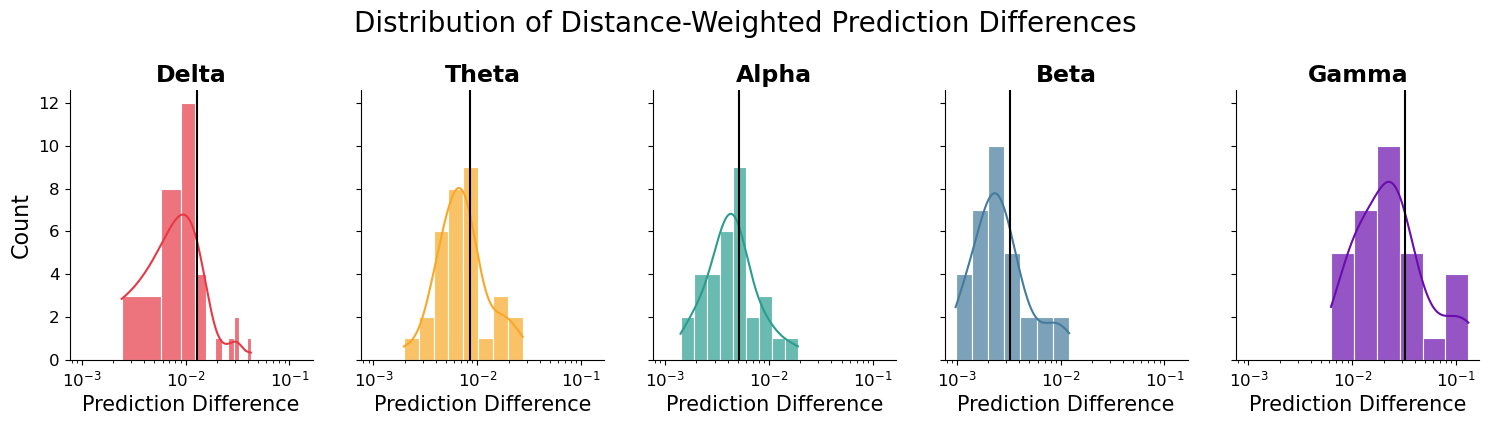

In [15]:
fig, _ = plot_frequency_band_distributions_average(all_subjects_avg_diffs, freq_bands, xlog=True)

In [16]:
fig.savefig("phase_distance_weighted_prediction_diffs.png", bbox_inches='tight', dpi=300)

In [21]:
cfg = load_config()
all_subjects_distances = {}
for subject_index in cfg.dataset.test_subject_indices:
    all_subjects_distances[subject_index] = load_distances(subject_index, phase_perturbations, rep=1)